# No-control random-initialization learning, then controlled evaluation

This notebook learns the graph identifier from many **no-control** rollouts, each started from a fresh bounded random initial state.  
Each training repeat uses **one campaign only** for data collection.  
After learning, the **final learned model** is evaluated under control exactly as before:
- learned control
- oracle control
- no control

A dedicated sanity-check cell is included to inspect the training initial states and their coverage of the opinion range.

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import os
import sys

def get_dir_n_levels_up(path, n):
    for _ in range(n):
        path = os.path.dirname(path)
    return path

proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
if proj_root not in sys.path:
    sys.path.append(proj_root)

print("proj_root:", proj_root)

proj_root: d:\Work\repos\RL\unknown_graph_networks


In [13]:
# =========================================================
# Imports + helpers
# =========================================================

import contextlib
import io
import time
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)

from opinion_dynamics.identify_nonlinear import (
    GraphIdentifierEnv,
    pairs_from_intermediate,
    train_graph_identifier,
)

from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control
from opinion_dynamics.experiments.rollouts import (
    rollout_with_v,
    rollout_with_v_intermediate,
    make_env_with_dynamics,
)
from opinion_dynamics.experiments.plots import (
    plot_impulse_node_trajectories,
    show_matrix_with_cell_grid,
    concat_intermediate,
)
from opinion_dynamics.experiments.metrics import graph_sanity


def _maybe_copy(v):
    if v is None:
        return None
    if isinstance(v, np.ndarray):
        return np.array(v, copy=True)
    try:
        return np.array(v, copy=True)
    except Exception:
        return v


def _env_template_kwargs_full(env, fallback_seed: int | None = None) -> dict[str, Any]:
    kwargs = dict(
        connectivity_matrix=np.array(env.connectivity_matrix, copy=True),
        num_agents=int(env.num_agents),
        max_u=np.array(env.max_u, copy=True),
        desired_opinion=float(env.desired_opinion),
        t_campaign=float(env.t_campaign),
        t_s=float(env.t_s),
        dynamics_model=str(getattr(env, "dynamics_model", "laplacian")),
        control_resistance=np.array(
            getattr(env, "control_resistance", np.zeros(env.num_agents)),
            copy=True,
        ),
        max_steps=int(getattr(env, "max_steps", 10_000)),
        opinion_end_tolerance=float(getattr(env, "opinion_end_tolerance", 0.01)),
        control_beta=float(getattr(env, "control_beta", 0.4)),
        normalize_reward=bool(getattr(env, "normalize_reward", False)),
        terminal_reward=float(getattr(env, "terminal_reward", 0.0)),
        terminate_when_converged=bool(getattr(env, "terminate_when_converged", True)),
        seed=int(getattr(env, "seed", fallback_seed))
        if getattr(env, "seed", None) is not None or fallback_seed is not None
        else None,
    )

    # Preserve dynamics-specific parameters when recreating fresh envs.
    for name in [
        "fj_lambda",
        "fj_prejudice",
        "hk_epsilon",
        "hk_include_self",
        "nonlinear_beta",
        "repulsion_epsilon",
        "repulsion_strength",
    ]:
        if hasattr(env, name):
            val = getattr(env, name)
            if val is not None:
                kwargs[name] = _maybe_copy(val)

    return kwargs


def _fresh_env_from_template(
    env_template,
    *,
    repeat_seed: int | None,
    initial_opinions: np.ndarray | None = None,
):
    EnvCls = env_template.__class__
    kwargs = _env_template_kwargs_full(env_template, fallback_seed=repeat_seed)
    kwargs["seed"] = repeat_seed
    if initial_opinions is not None:
        kwargs["initial_opinions"] = np.array(initial_opinions, copy=True)
    env = EnvCls(**kwargs)
    return env, kwargs


def sample_init_opinions(
    N: int,
    rng: np.random.Generator,
    mode: str = "permuted_linspace",
    low: float = 0.01,
    high: float = 0.99,
) -> np.ndarray:
    if mode == "permuted_linspace":
        x0 = np.linspace(low, high, N, dtype=float)
        rng.shuffle(x0)
        return x0
    if mode == "uniform":
        return rng.uniform(low, high, size=N).astype(float)
    raise ValueError(f"Unknown init_mode: {mode}")


def summarize_training_inits(x0_list: np.ndarray) -> pd.DataFrame:
    rows = []
    for r in range(x0_list.shape[0]):
        x = np.asarray(x0_list[r], dtype=float)
        rows.append(
            dict(
                repeat=r,
                min=float(x.min()),
                q10=float(np.quantile(x, 0.10)),
                q25=float(np.quantile(x, 0.25)),
                median=float(np.median(x)),
                q75=float(np.quantile(x, 0.75)),
                q90=float(np.quantile(x, 0.90)),
                max=float(x.max()),
                mean=float(x.mean()),
                std=float(x.std()),
                range=float(x.max() - x.min()),
            )
        )
    return pd.DataFrame(rows)

In [14]:
# =========================================================
# Core experiment:
# learn from MANY no-control, one-campaign rollouts
# with fresh bounded random initial states.
# Then evaluate the FINAL learned model under control.
# =========================================================

def run_repeated_nocontrol_singlecampaign_id_on_env(
    env_template,
    *,
    num_repeats=100,
    init_mode="permuted_linspace",
    init_low=0.01,
    init_high=0.99,
    init_seed_base: int = 12345,
    learn_num_campaigns=1,
    eval_num_campaigns=5,
    B_campaign=1.0,
    lr=1e-3,
    device="cpu",
    suppress_fit_logs=True,
    fit_max_steps=50_000,
    fit_mae_stop=1e-3,
    fit_batch_size=64,
    fit_check_every=200,
    identifier_kwargs=None,
    repeat_seed_stride: int = 10_000,
    eval_seed_offset: int = 999_999,
):
    """
    Learning phase:
      - same graph topology
      - fresh random x0 each repeat
      - NO CONTROL only
      - collect data from learn_num_campaigns (default: 1) campaign rollouts
      - accumulate transition pairs and refit after each repeat

    Evaluation phase:
      - fixed evaluation x0
      - run eval_num_campaigns with:
          * learned control (using v_hat from A_hat)
          * oracle control (using v_true)
          * no control
    """
    N = int(env_template.num_agents)
    A_true = np.asarray(env_template.connectivity_matrix, dtype=float)
    v_true = compute_eigenvector_centrality(compute_laplacian(A_true))

    base_seed = int(getattr(env_template, "seed", 0) or 0)

    gi = GraphIdentifierEnv(
        N=N,
        s=float(env_template.t_s),
        zero_diag=True,
        **({} if identifier_kwargs is None else identifier_kwargs),
    )

    buf_x: list[np.ndarray] = []
    buf_y: list[np.ndarray] = []
    repeat_rows: list[dict[str, Any]] = []
    repeat_artifacts: list[dict[str, Any]] = []
    train_x0s: list[np.ndarray] = []

    A_hat = None
    v_hat = None

    def _fit_current():
        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)

        if suppress_fit_logs:
            f = io.StringIO()
            with contextlib.redirect_stdout(f):
                A_local = train_graph_identifier(
                    gi,
                    X,
                    Y,
                    lr=lr,
                    batch_size=fit_batch_size,
                    max_steps=fit_max_steps,
                    mae_stop=fit_mae_stop,
                    device=device,
                    fit_check_every=fit_check_every,
                )
        else:
            A_local = train_graph_identifier(
                gi,
                X,
                Y,
                lr=lr,
                batch_size=fit_batch_size,
                max_steps=fit_max_steps,
                mae_stop=fit_mae_stop,
                device=device,
                fit_check_every=fit_check_every,
            )
        return A_local

    eval_rng = np.random.default_rng(base_seed + eval_seed_offset)
    eval_x0 = sample_init_opinions(
        N,
        eval_rng,
        mode=init_mode,
        low=init_low,
        high=init_high,
    )

    for repeat_idx in range(int(num_repeats)):
        rng = np.random.default_rng(init_seed_base + repeat_idx)
        x0_train = sample_init_opinions(
            N,
            rng,
            mode=init_mode,
            low=init_low,
            high=init_high,
        )
        train_x0s.append(np.array(x0_train, copy=True))

        repeat_seed = base_seed + repeat_seed_stride * (repeat_idx + 1)
        env, env_kwargs = _fresh_env_from_template(
            env_template,
            repeat_seed=repeat_seed,
            initial_opinions=x0_train,
        )

        states_train = []
        actions_train = []
        rewards_train = []
        intermediate_states_list = []
        intermediate_times_list = []

        timing = {
            "fit_time": 0.0,
            "step_time": 0.0,
            "fit_calls": 0,
            "step_calls": 0,
        }

        x, _ = env.reset()
        states_train.append(np.array(x, copy=True))

        def _record_intermediate(info_obj):
            inter = info_obj.get("intermediate_states", None)
            if inter is None:
                intermediate_states_list.append(None)
                intermediate_times_list.append(None)
                return
            inter_arr = np.asarray(inter, dtype=float)
            dt = getattr(env, "t_s", None)
            t = (
                np.arange(inter_arr.shape[0], dtype=float)
                if dt is None
                else dt * np.arange(inter_arr.shape[0], dtype=float)
            )
            intermediate_states_list.append(inter_arr)
            intermediate_times_list.append(t)

        def _step(u):
            t0 = time.perf_counter()
            out = env.step(u)
            timing["step_time"] += time.perf_counter() - t0
            timing["step_calls"] += 1
            return out

        def _fit():
            nonlocal A_hat, v_hat
            t0 = time.perf_counter()
            A_hat = _fit_current()
            v_hat = compute_eigenvector_centrality(compute_laplacian(A_hat))
            timing["fit_time"] += time.perf_counter() - t0
            timing["fit_calls"] += 1
            return A_hat, v_hat

        for _k in range(int(learn_num_campaigns)):
            u0 = np.zeros(N, dtype=float)
            x_next, r, done, trunc, info_k = _step(u0)

            actions_train.append(u0.copy())
            rewards_train.append(float(r))
            states_train.append(np.array(x_next, copy=True))
            _record_intermediate(info_k)

            inter = info_k.get("intermediate_states", None)
            if inter is None:
                raise RuntimeError(
                    "env.step did not return info['intermediate_states']; "
                    "cannot build transition pairs."
                )

            Xp, Yp = pairs_from_intermediate(inter)
            buf_x.append(Xp)
            buf_y.append(Yp)

            if done or trunc:
                break

        A_hat, v_hat = _fit()

        states_train_arr = np.asarray(states_train, dtype=float)
        A_hat_final = np.asarray(A_hat, dtype=float)
        v_hat_final = np.asarray(v_hat, dtype=float)

        env_eval_learn, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )
        env_eval_oracle, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )
        env_eval_noc, _ = _fresh_env_from_template(
            env_template,
            repeat_seed=base_seed + eval_seed_offset,
            initial_opinions=eval_x0,
        )

        states_learn = rollout_with_v(
            env_eval_learn,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            v_hat_final,
        )
        states_oracle = rollout_with_v(
            env_eval_oracle,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            v_true,
        )
        states_noc = rollout_with_v(
            env_eval_noc,
            eval_x0,
            int(eval_num_campaigns),
            B_campaign,
            None,
        )

        T = min(states_learn.shape[0], states_oracle.shape[0], states_noc.shape[0])
        sl = np.asarray(states_learn[:T], dtype=float)
        so = np.asarray(states_oracle[:T], dtype=float)
        sn = np.asarray(states_noc[:T], dtype=float)

        mean_le = sl.mean(axis=1)
        mean_or = so.mean(axis=1)
        mean_nc = sn.mean(axis=1)
        vx_le = sl @ v_true
        vx_or = so @ v_true

        mean_err = np.abs(mean_le - mean_or)
        vx_err = np.abs(vx_le - vx_or)

        row = dict(
            seed=int(base_seed),
            repeat=int(repeat_idx),
            repeat_seed=int(repeat_seed),
            dynamics=str(getattr(env, "dynamics_model", "laplacian")),
            init_mode=str(init_mode),
            learn_num_campaigns=int(learn_num_campaigns),
            eval_num_campaigns=int(eval_num_campaigns),
            N=int(N),
            train_pairs_total=int(sum(x.shape[0] for x in buf_x)),
            v_L1_final=float(np.sum(np.abs(v_hat_final - v_true))),
            A_Fro_final=float(np.linalg.norm(A_hat_final - A_true, ord="fro")),
            A_MAE_final=float(np.mean(np.abs(A_hat_final - A_true))),
            mean_oracle_end=float(mean_or[-1]),
            mean_learn_end=float(mean_le[-1]),
            mean_noc_end=float(mean_nc[-1]),
            mean_gap_to_oracle_end=float(np.abs(mean_le[-1] - mean_or[-1])),
            mean_gain_vs_noc_end=float(mean_le[-1] - mean_nc[-1]),
            mean_err_avg=float(mean_err.mean()),
            mean_err_max=float(mean_err.max()),
            vx_gap_to_oracle_end=float(np.abs(vx_le[-1] - vx_or[-1])),
            vx_err_avg=float(vx_err.mean()),
            vx_err_max=float(vx_err.max()),
            time_fit_inner=float(timing["fit_time"]),
            time_step_inner=float(timing["step_time"]),
            fit_calls_inner=int(timing["fit_calls"]),
            step_calls_inner=int(timing["step_calls"]),
        )
        repeat_rows.append(row)

        repeat_artifacts.append(
            dict(
                env=env,
                env_template_kwargs=env_kwargs,
                x0_train=np.asarray(x0_train, dtype=float),
                x0_eval=np.asarray(eval_x0, dtype=float),
                states_nocontrol_train=states_train_arr,
                actions_nocontrol_train=np.asarray(actions_train, dtype=float),
                rewards_nocontrol_train=np.asarray(rewards_train, dtype=float),
                A_hat_final=A_hat_final,
                v_hat_final=v_hat_final,
                A_true=A_true,
                v_true=v_true,
                states_learn=np.asarray(states_learn, dtype=float),
                states_oracle=np.asarray(states_oracle, dtype=float),
                states_nocontrol_eval=np.asarray(states_noc, dtype=float),
                intermediate_states_list=intermediate_states_list,
                intermediate_times_list=intermediate_times_list,
                train_pairs_total=row["train_pairs_total"],
                timing=timing,
            )
        )

    return {
        "rows": repeat_rows,
        "artifacts": repeat_artifacts,
        "A_true": A_true,
        "v_true": v_true,
        "A_hat_final": np.asarray(A_hat, dtype=float) if A_hat is not None else None,
        "v_hat_final": np.asarray(v_hat, dtype=float) if v_hat is not None else None,
        "train_pairs_total": int(sum(x.shape[0] for x in buf_x)),
        "x0_eval": np.asarray(eval_x0, dtype=float),
        "train_x0s": np.stack(train_x0s, axis=0),
    }


def run_multi_seed_nocontrol_singlecampaign_experiment_dynamics(
    *,
    seeds=range(10),
    repeats_per_seed=100,
    dynamics_model="laplacian",
    init_mode="permuted_linspace",
    learn_num_campaigns=1,
    eval_num_campaigns=5,
    B_campaign=1.0,
    lr=1e-3,
    device="cpu",
    suppress_fit_logs=True,
    fit_max_steps=None,
    fit_mae_stop=None,
    fit_batch_size=None,
    fit_check_every=None,
    identifier_kwargs: dict | None = None,
    repeat_seed_stride: int = 10_000,
    return_artifacts: bool = False,
):
    if fit_max_steps is None:
        fit_max_steps = 50_000 if dynamics_model == "laplacian" else 2_000
    if fit_mae_stop is None:
        fit_mae_stop = 1e-3 if dynamics_model == "laplacian" else 5e-3
    if fit_batch_size is None:
        fit_batch_size = 64 if dynamics_model == "laplacian" else 256
    if fit_check_every is None:
        fit_check_every = 200

    env_factory = EnvironmentFactory()
    rows = []
    artifacts_by_seed = {} if return_artifacts else None

    for seed in seeds:
        env_template = make_env_with_dynamics(
            env_factory,
            seed=int(seed),
            dynamics_model=dynamics_model,
        )
        out = run_repeated_nocontrol_singlecampaign_id_on_env(
            env_template,
            num_repeats=repeats_per_seed,
            init_mode=init_mode,
            learn_num_campaigns=learn_num_campaigns,
            eval_num_campaigns=eval_num_campaigns,
            B_campaign=B_campaign,
            lr=lr,
            device=device,
            suppress_fit_logs=suppress_fit_logs,
            fit_max_steps=fit_max_steps,
            fit_mae_stop=fit_mae_stop,
            fit_batch_size=fit_batch_size,
            fit_check_every=fit_check_every,
            identifier_kwargs=identifier_kwargs,
            repeat_seed_stride=repeat_seed_stride,
        )
        rows.extend(out["rows"])
        if return_artifacts:
            artifacts_by_seed[int(seed)] = out

    df = pd.DataFrame(rows).sort_values(["seed", "repeat"]).reset_index(drop=True)
    if return_artifacts:
        return df, artifacts_by_seed
    return df

In [ ]:
# =========================================================
# Main experiment across propagation methods
# Learn from many one-campaign no-control rollouts.
# Evaluate final learned model under control.
# =========================================================

seeds = range(10)
B_campaign = 1.0

LEARN_NUM_CAMPAIGNS = 1
EVAL_NUM_CAMPAIGNS = 5

FIT_MAX_STEPS = 5_000
NUM_REPEATS = 100

INIT_MODE = "permuted_linspace"   # safer coverage of [0.01, 0.99] each repeat
# INIT_MODE = "uniform"

DYNAMICS_LIST = [
    "laplacian",
    "coca",
    "friedkinjohnsen",
    "hegselmannkrause",
    "nonlinearinfluence",
    # "repulsion",
]

FIT_BY_DYNAMICS = {
    "laplacian": dict(fit_max_steps=FIT_MAX_STEPS, fit_mae_stop=1e-2, fit_batch_size=256, fit_check_every=200),
    "coca": dict(fit_max_steps=FIT_MAX_STEPS, fit_mae_stop=2e-2, fit_batch_size=512, fit_check_every=200),
    "friedkinjohnsen": dict(fit_max_steps=FIT_MAX_STEPS, fit_mae_stop=2e-2, fit_batch_size=256, fit_check_every=200),
    "hegselmannkrause": dict(fit_max_steps=FIT_MAX_STEPS, fit_mae_stop=2e-2, fit_batch_size=256, fit_check_every=200),
    "nonlinearinfluence": dict(fit_max_steps=FIT_MAX_STEPS, fit_mae_stop=2e-2, fit_batch_size=256, fit_check_every=200),
}

dfs_final = []
dfs_all = {}

for dyn in DYNAMICS_LIST:
    print(f"=== Running {dyn} | learn from no-control single-campaign random inits ===")
    df_all = run_multi_seed_nocontrol_singlecampaign_experiment_dynamics(
        seeds=seeds,
        repeats_per_seed=NUM_REPEATS,
        dynamics_model=dyn,
        init_mode=INIT_MODE,
        learn_num_campaigns=LEARN_NUM_CAMPAIGNS,
        eval_num_campaigns=EVAL_NUM_CAMPAIGNS,
        B_campaign=B_campaign,
        suppress_fit_logs=True,
        **FIT_BY_DYNAMICS[dyn],
    )
    dfs_all[dyn] = df_all

    df_final = (
        df_all.sort_values(["seed", "repeat"])
        .groupby("seed", as_index=False, group_keys=False)
        .tail(1)
        .reset_index(drop=True)
    )
    dfs_final.append(df_final)

df = pd.concat(dfs_final, axis=0).reset_index(drop=True)
display(df)

print("=== Aggregate by dynamics (final repeat only) ===")
cols = [
    "repeat",
    "train_pairs_total",
    "v_L1_final",
    "A_MAE_final",
    "mean_gap_to_oracle_end",
    "mean_gain_vs_noc_end",
    "vx_gap_to_oracle_end",
    "time_fit_inner",
]
display(df.groupby("dynamics")[cols].describe().T)

for metric, ylabel, title in [
    ("A_MAE_final", "MAE(A_hat, A_true)", "Adjacency MAE vs seed (final learned model)"),
    ("v_L1_final", "||v_hat - v_true||_1", "Centrality error vs seed (final learned model)"),
    ("mean_gap_to_oracle_end", "oracle gap", "Mean gap to oracle vs seed (final learned model)"),
    ("mean_gain_vs_noc_end", "gain over no control", "Final mean gain over no-control vs seed"),
]:
    plt.figure(figsize=(10, 4))
    for dyn in DYNAMICS_LIST:
        sub = df[df["dynamics"] == dyn].sort_values("seed")
        plt.plot(sub["seed"], sub[metric], marker="o", label=dyn)
    plt.xlabel("seed")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

=== Running laplacian | learn from no-control single-campaign random inits ===
=== Running coca | learn from no-control single-campaign random inits ===


In [ ]:
# =========================================================
# Single-seed detailed runs for ALL dynamics
# (same style as the previous repeated notebook)
# =========================================================

SEED_TO_PLOT = 10
NUM_REPEATS = 100
REPEAT_TO_PLOT = NUM_REPEATS - 1

INIT_MODE = "permuted_linspace"
LEARN_NUM_CAMPAIGNS = 1
EVAL_NUM_CAMPAIGNS = 5

env_factory = EnvironmentFactory()

outs_by_dyn = {}
metrics_by_dyn = {}
art_by_dyn = {}

for DYNAMICS in DYNAMICS_LIST:
    print("\n" + "=" * 80)
    print(f"=== DYNAMICS: {DYNAMICS} | SEED {SEED_TO_PLOT} ===")
    print("=" * 80)

    FIT_KW = FIT_BY_DYNAMICS[DYNAMICS]
    env_template = make_env_with_dynamics(
        env_factory,
        seed=SEED_TO_PLOT,
        dynamics_model=DYNAMICS,
    )

    out = run_repeated_nocontrol_singlecampaign_id_on_env(
        env_template,
        num_repeats=NUM_REPEATS,
        init_mode=INIT_MODE,
        learn_num_campaigns=LEARN_NUM_CAMPAIGNS,
        eval_num_campaigns=EVAL_NUM_CAMPAIGNS,
        B_campaign=B_campaign,
        lr=1e-3,
        device="cpu",
        suppress_fit_logs=True,
        **FIT_KW,
    )

    metrics = out["rows"][REPEAT_TO_PLOT]
    art = out["artifacts"][REPEAT_TO_PLOT]

    outs_by_dyn[DYNAMICS] = out
    metrics_by_dyn[DYNAMICS] = metrics
    art_by_dyn[DYNAMICS] = art

    print(f"=== FINAL REPEAT {REPEAT_TO_PLOT + 1}/{NUM_REPEATS} ===")
    print(f"train_pairs_total: {metrics['train_pairs_total']}")
    print("=== METRICS ===")
    for k, v in metrics.items():
        print(f"{k}: {v}")


=== DYNAMICS: laplacian | SEED 10 ===
[identifier-init] class=GraphIdentifierEnvFreeProp module=opinion_dynamics.identify_freeprop file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_freeprop.py:8
=== FINAL REPEAT 100/100 ===
train_pairs_total: 400
=== METRICS ===
seed: 10
repeat: 99
repeat_seed: 1000010
dynamics: laplacian
init_mode: permuted_linspace
learn_num_campaigns: 1
eval_num_campaigns: 5
N: 15
train_pairs_total: 400
v_L1_final: 0.2422075295893672
A_Fro_final: 0.8078607685306856
A_MAE_final: 0.03350368967457187
mean_oracle_end: 0.7206617760775239
mean_learn_end: 0.716239009359635
mean_noc_end: 0.5372496287298052
mean_gap_to_oracle_end: 0.004422766717888882
mean_gain_vs_noc_end: 0.17898938062982983
mean_err_avg: 0.0017428615135477814
mean_err_max: 0.004422766717888882
vx_gap_to_oracle_end: 0.005709777507404312
vx_err_avg: 0.0028821662145919005
vx_err_max: 0.0064942550268076715
time_fit_inner: 0.010527700011152774
time_step_inner: 4.320003790780902e-05
fit_cal


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: laplacian ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,2.901149e+01,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.010000,1.743463e-18,0.010000,0.010000,0.010000,0.010000,0.010000
q10,100.0,0.108000,4.184310e-17,0.108000,0.108000,0.108000,0.108000,0.108000
q25,100.0,0.255000,1.115816e-16,0.255000,0.255000,0.255000,0.255000,0.255000
median,100.0,0.500000,0.000000e+00,0.500000,0.500000,0.500000,0.500000,0.500000
q75,100.0,0.745000,2.231632e-16,0.745000,0.745000,0.745000,0.745000,0.745000
q90,100.0,0.892000,4.463264e-16,0.892000,0.892000,0.892000,0.892000,0.892000
max,100.0,0.990000,1.115816e-16,0.990000,0.990000,0.990000,0.990000,0.990000
mean,100.0,0.500000,4.667794e-17,0.500000,0.500000,0.500000,0.500000,0.500000
std,100.0,0.302435,1.932650e-17,0.302435,0.302435,0.302435,0.302435,0.302435


Overall value summary:


count    1500.000000
mean        0.500000
std         0.302535
min         0.010000
25%         0.220000
50%         0.500000
75%         0.780000
max         0.990000
dtype: float64

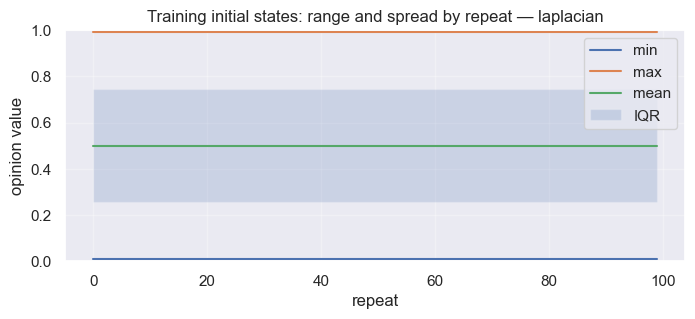

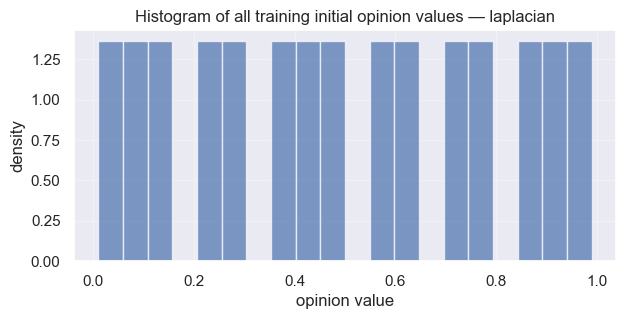

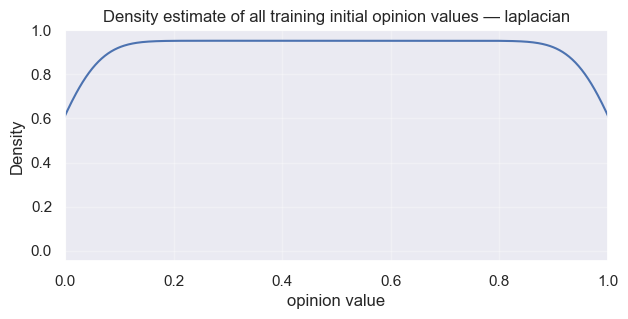

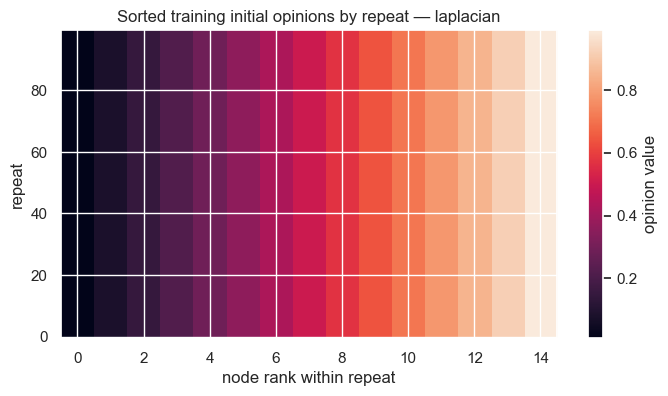


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: coca ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,2.901149e+01,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.010000,1.743463e-18,0.010000,0.010000,0.010000,0.010000,0.010000
q10,100.0,0.108000,4.184310e-17,0.108000,0.108000,0.108000,0.108000,0.108000
q25,100.0,0.255000,1.115816e-16,0.255000,0.255000,0.255000,0.255000,0.255000
median,100.0,0.500000,0.000000e+00,0.500000,0.500000,0.500000,0.500000,0.500000
q75,100.0,0.745000,2.231632e-16,0.745000,0.745000,0.745000,0.745000,0.745000
q90,100.0,0.892000,4.463264e-16,0.892000,0.892000,0.892000,0.892000,0.892000
max,100.0,0.990000,1.115816e-16,0.990000,0.990000,0.990000,0.990000,0.990000
mean,100.0,0.500000,4.667794e-17,0.500000,0.500000,0.500000,0.500000,0.500000
std,100.0,0.302435,1.932650e-17,0.302435,0.302435,0.302435,0.302435,0.302435


Overall value summary:


count    1500.000000
mean        0.500000
std         0.302535
min         0.010000
25%         0.220000
50%         0.500000
75%         0.780000
max         0.990000
dtype: float64

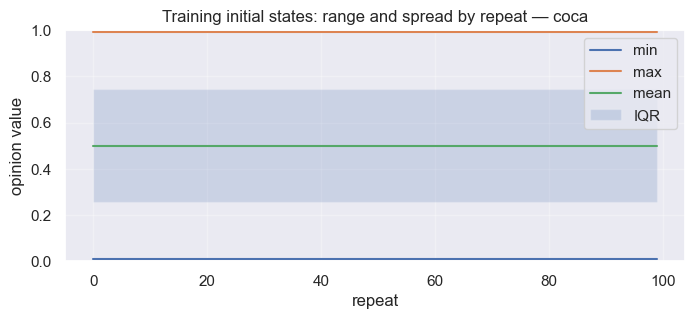

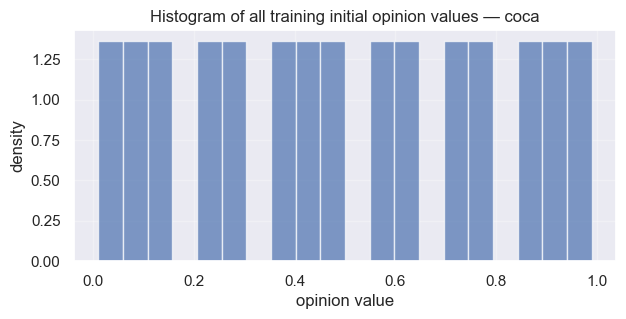

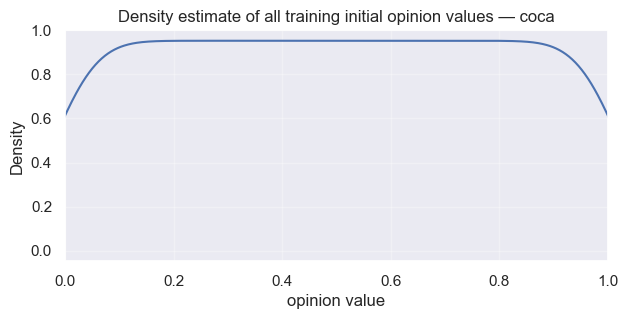

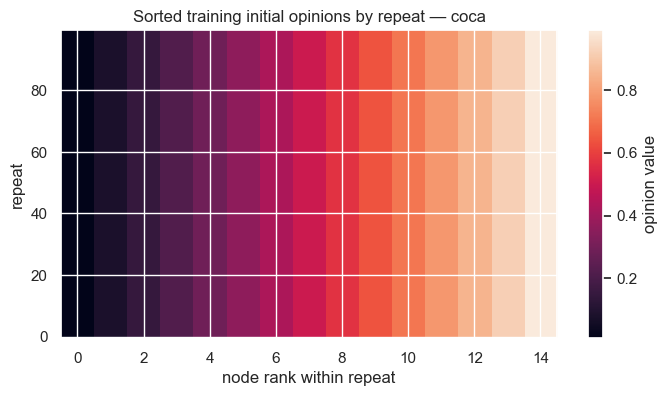


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: friedkinjohnsen ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,2.901149e+01,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.010000,1.743463e-18,0.010000,0.010000,0.010000,0.010000,0.010000
q10,100.0,0.108000,4.184310e-17,0.108000,0.108000,0.108000,0.108000,0.108000
q25,100.0,0.255000,1.115816e-16,0.255000,0.255000,0.255000,0.255000,0.255000
median,100.0,0.500000,0.000000e+00,0.500000,0.500000,0.500000,0.500000,0.500000
q75,100.0,0.745000,2.231632e-16,0.745000,0.745000,0.745000,0.745000,0.745000
q90,100.0,0.892000,4.463264e-16,0.892000,0.892000,0.892000,0.892000,0.892000
max,100.0,0.990000,1.115816e-16,0.990000,0.990000,0.990000,0.990000,0.990000
mean,100.0,0.500000,4.667794e-17,0.500000,0.500000,0.500000,0.500000,0.500000
std,100.0,0.302435,1.932650e-17,0.302435,0.302435,0.302435,0.302435,0.302435


Overall value summary:


count    1500.000000
mean        0.500000
std         0.302535
min         0.010000
25%         0.220000
50%         0.500000
75%         0.780000
max         0.990000
dtype: float64

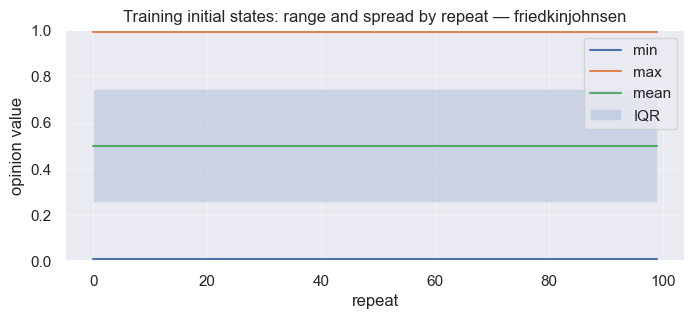

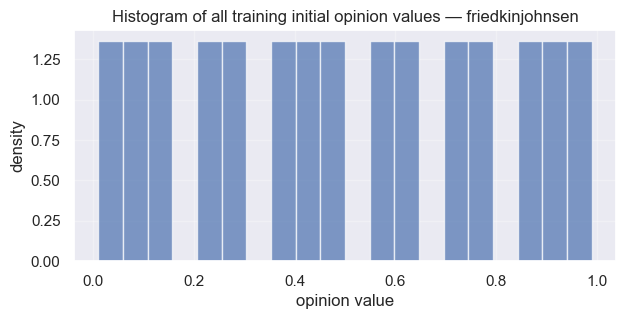

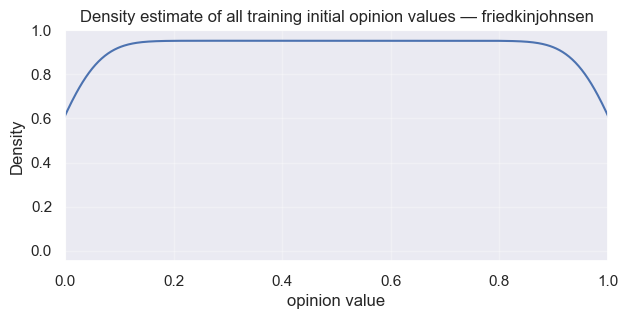

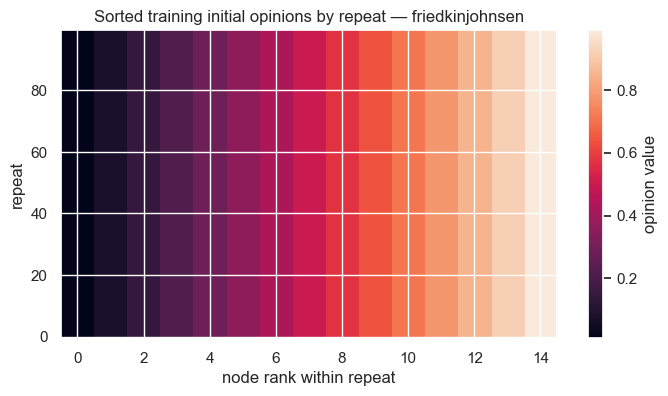


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: hegselmannkrause ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,2.901149e+01,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.010000,1.743463e-18,0.010000,0.010000,0.010000,0.010000,0.010000
q10,100.0,0.108000,4.184310e-17,0.108000,0.108000,0.108000,0.108000,0.108000
q25,100.0,0.255000,1.115816e-16,0.255000,0.255000,0.255000,0.255000,0.255000
median,100.0,0.500000,0.000000e+00,0.500000,0.500000,0.500000,0.500000,0.500000
q75,100.0,0.745000,2.231632e-16,0.745000,0.745000,0.745000,0.745000,0.745000
q90,100.0,0.892000,4.463264e-16,0.892000,0.892000,0.892000,0.892000,0.892000
max,100.0,0.990000,1.115816e-16,0.990000,0.990000,0.990000,0.990000,0.990000
mean,100.0,0.500000,4.667794e-17,0.500000,0.500000,0.500000,0.500000,0.500000
std,100.0,0.302435,1.932650e-17,0.302435,0.302435,0.302435,0.302435,0.302435


Overall value summary:


count    1500.000000
mean        0.500000
std         0.302535
min         0.010000
25%         0.220000
50%         0.500000
75%         0.780000
max         0.990000
dtype: float64

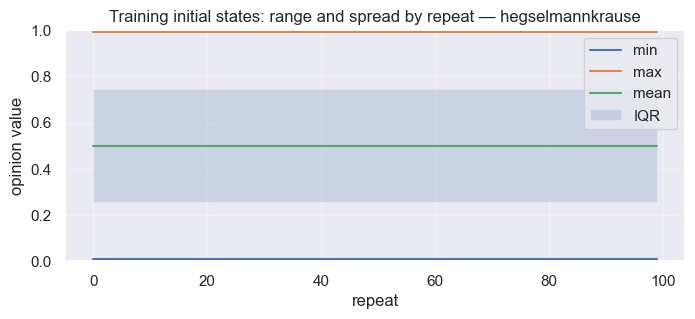

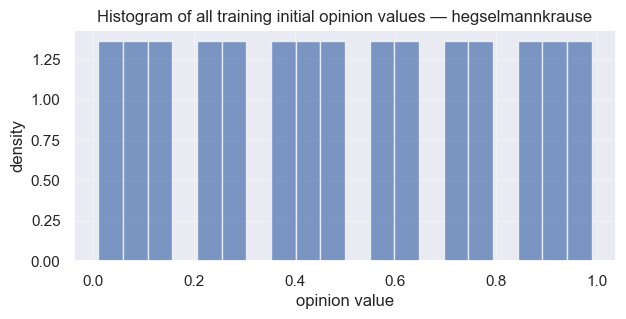

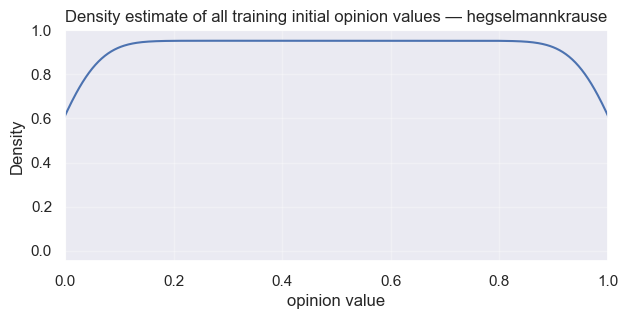

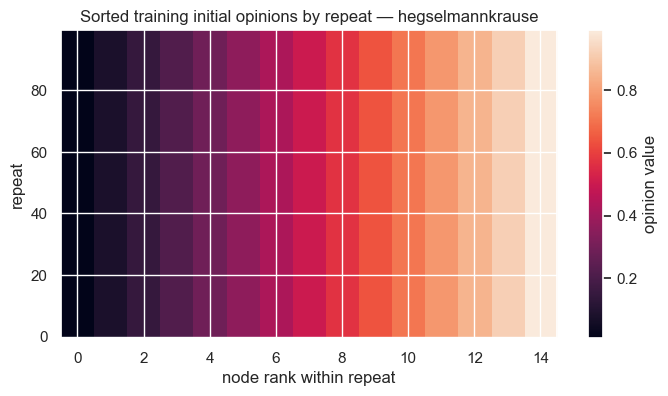


--------------------------------------------------------------------------------
=== TRAINING-INIT SANITY: nonlinearinfluence ===
--------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
repeat,100.0,49.500000,2.901149e+01,0.000000,24.750000,49.500000,74.250000,99.000000
min,100.0,0.010000,1.743463e-18,0.010000,0.010000,0.010000,0.010000,0.010000
q10,100.0,0.108000,4.184310e-17,0.108000,0.108000,0.108000,0.108000,0.108000
q25,100.0,0.255000,1.115816e-16,0.255000,0.255000,0.255000,0.255000,0.255000
median,100.0,0.500000,0.000000e+00,0.500000,0.500000,0.500000,0.500000,0.500000
q75,100.0,0.745000,2.231632e-16,0.745000,0.745000,0.745000,0.745000,0.745000
q90,100.0,0.892000,4.463264e-16,0.892000,0.892000,0.892000,0.892000,0.892000
max,100.0,0.990000,1.115816e-16,0.990000,0.990000,0.990000,0.990000,0.990000
mean,100.0,0.500000,4.667794e-17,0.500000,0.500000,0.500000,0.500000,0.500000
std,100.0,0.302435,1.932650e-17,0.302435,0.302435,0.302435,0.302435,0.302435


Overall value summary:


count    1500.000000
mean        0.500000
std         0.302535
min         0.010000
25%         0.220000
50%         0.500000
75%         0.780000
max         0.990000
dtype: float64

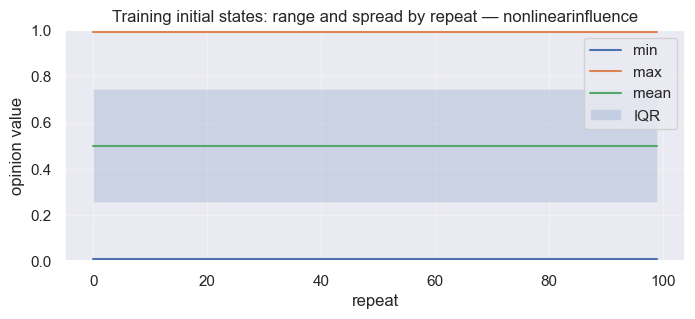

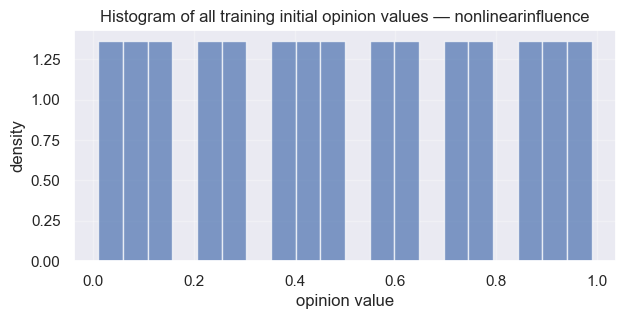

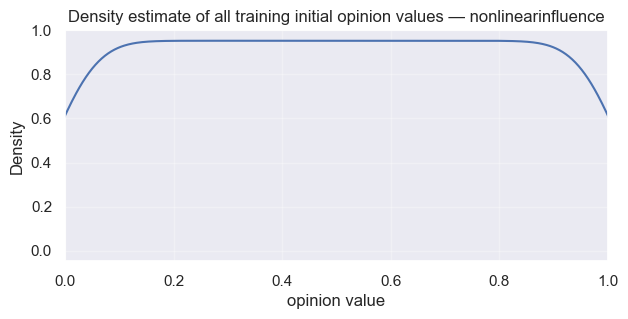

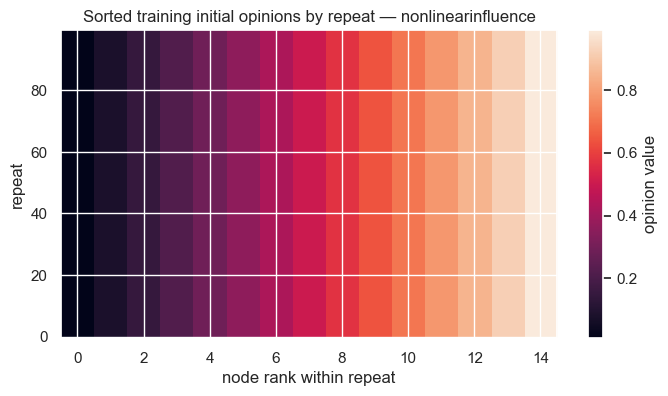

In [ ]:
# =========================================================
# Sanity check: inspect the training initial states
# NOTE: the same sampling procedure is used for every dynamics.
# We still summarize it for each dynamics so you can verify.
# =========================================================

for DYNAMICS in DYNAMICS_LIST:
    out = outs_by_dyn[DYNAMICS]
    all_x0_train = np.asarray(out["train_x0s"], dtype=float)
    summary_df = summarize_training_inits(all_x0_train)

    print("\n" + "-" * 80)
    print(f"=== TRAINING-INIT SANITY: {DYNAMICS} ===")
    print("-" * 80)
    display(summary_df.describe().T)

    flat = all_x0_train.ravel()
    print("Overall value summary:")
    display(pd.Series(flat).describe())

    plt.figure(figsize=(8, 3))
    plt.plot(summary_df["repeat"], summary_df["min"], label="min")
    plt.plot(summary_df["repeat"], summary_df["max"], label="max")
    plt.plot(summary_df["repeat"], summary_df["mean"], label="mean")
    plt.fill_between(summary_df["repeat"], summary_df["q25"], summary_df["q75"], alpha=0.2, label="IQR")
    plt.title(f"Training initial states: range and spread by repeat — {DYNAMICS}")
    plt.xlabel("repeat")
    plt.ylabel("opinion value")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.hist(flat, bins=20, density=True, alpha=0.7)
    plt.title(f"Histogram of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.ylabel("density")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 3))
    pd.Series(flat).plot(kind="density")
    plt.title(f"Density estimate of all training initial opinion values — {DYNAMICS}")
    plt.xlabel("opinion value")
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

    sorted_x0 = np.sort(all_x0_train, axis=1)
    plt.figure(figsize=(8, 4))
    plt.imshow(sorted_x0, aspect="auto", origin="lower")
    plt.colorbar(label="opinion value")
    plt.title(f"Sorted training initial opinions by repeat — {DYNAMICS}")
    plt.xlabel("node rank within repeat")
    plt.ylabel("repeat")
    plt.show()


=== DETAILED ANALYSIS: laplacian | SEED 10 ===
x0_train: [0.01 0.22 0.78 0.15 0.43 0.71 0.5  0.29 0.99 0.36 0.85 0.08 0.92 0.57
 0.64]
x0_eval : [0.43 0.22 0.64 0.5  0.36 0.99 0.85 0.29 0.92 0.71 0.08 0.15 0.01 0.57
 0.78]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 1.0017820031950908
edges: 39
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.999999885330908
row_sum_mean: 0.9999999845090012
row_sum_max: 1.000000067986548
asym: 0.9651501800412772
edges: 210
sink_sizes: [15]
has_singleton_sink: False


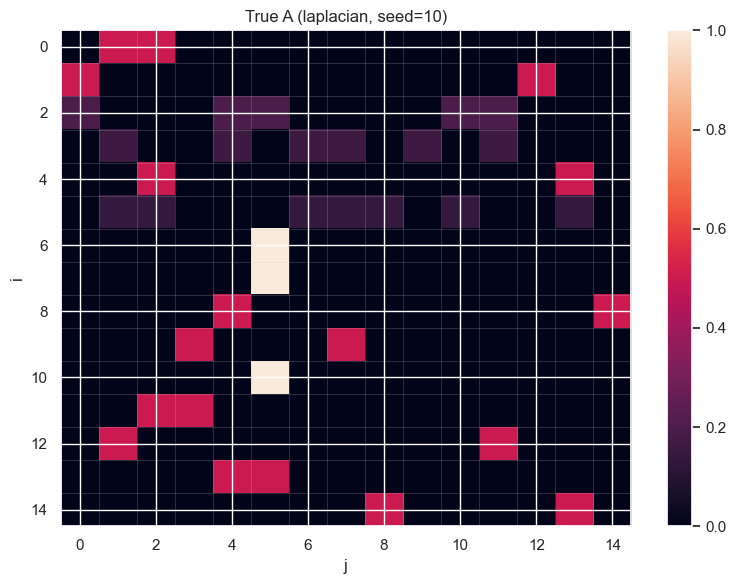

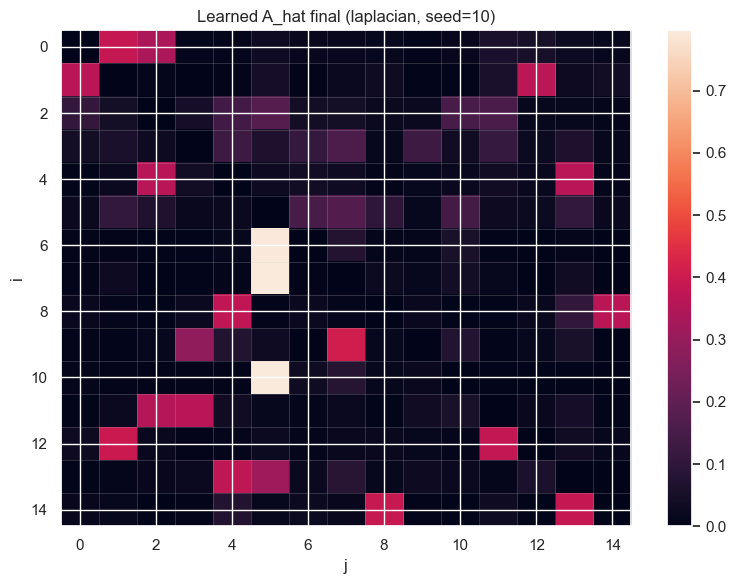

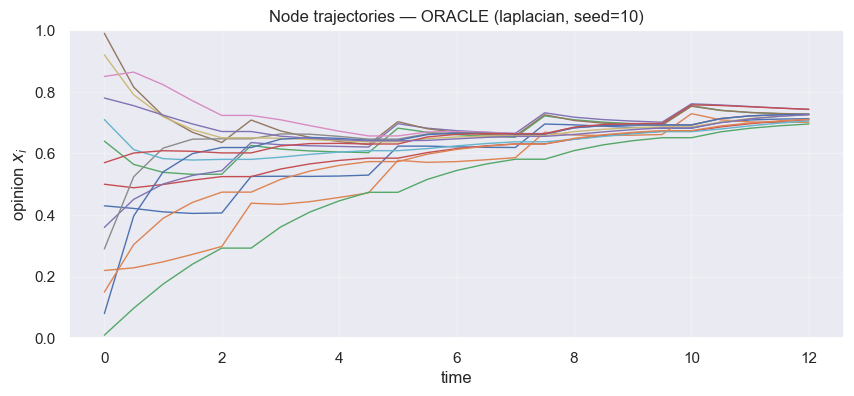

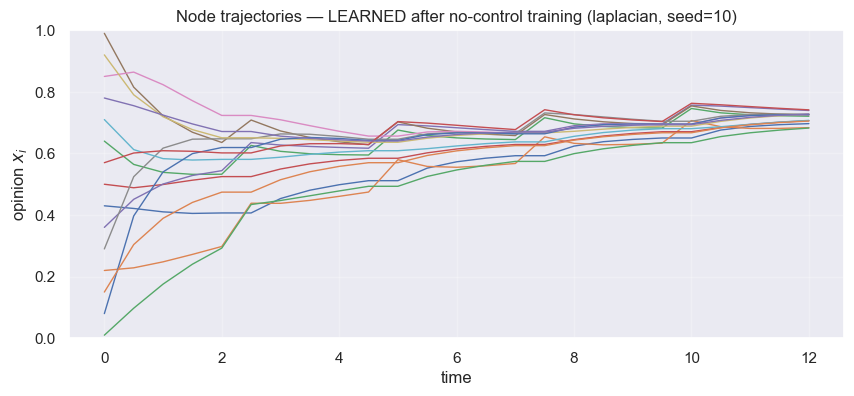


=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.2422075295893672


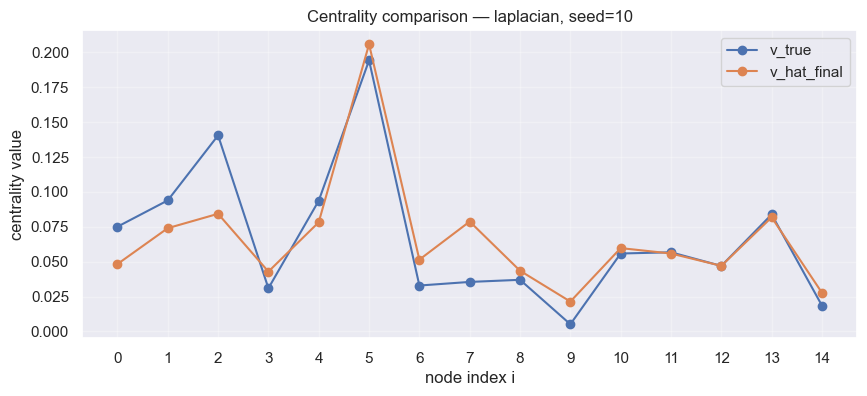

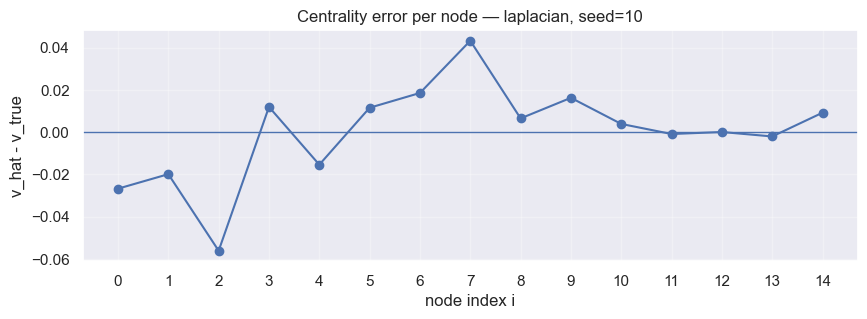

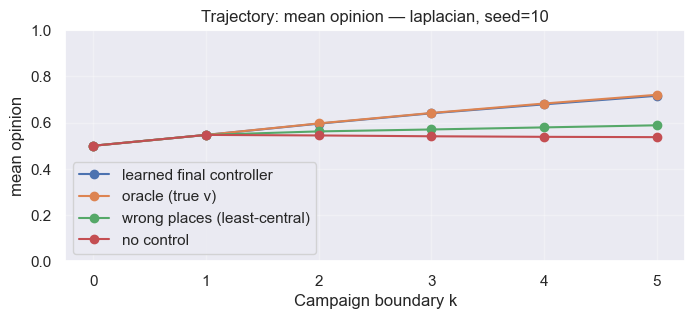


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.0
learned states[1] vs nocontrol states[1] L_inf: 0.0

=== DETAILED ANALYSIS: coca | SEED 10 ===
x0_train: [0.01 0.22 0.78 0.15 0.43 0.71 0.5  0.29 0.99 0.36 0.85 0.08 0.92 0.57
 0.64]
x0_eval : [0.43 0.22 0.64 0.5  0.36 0.99 0.85 0.29 0.92 0.71 0.08 0.15 0.01 0.57
 0.78]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 1.0017820031950908
edges: 39
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.999999885854777
row_sum_mean: 0.9999999901575696
row_sum_max: 1.0000000969448593
asym: 0.8955309329430382
edges: 210
sink_sizes: [15]
has_singleton_sink: False


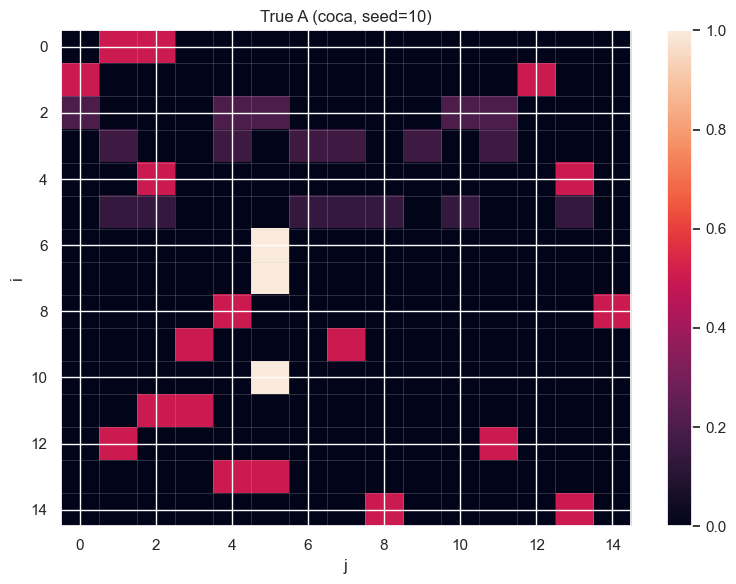

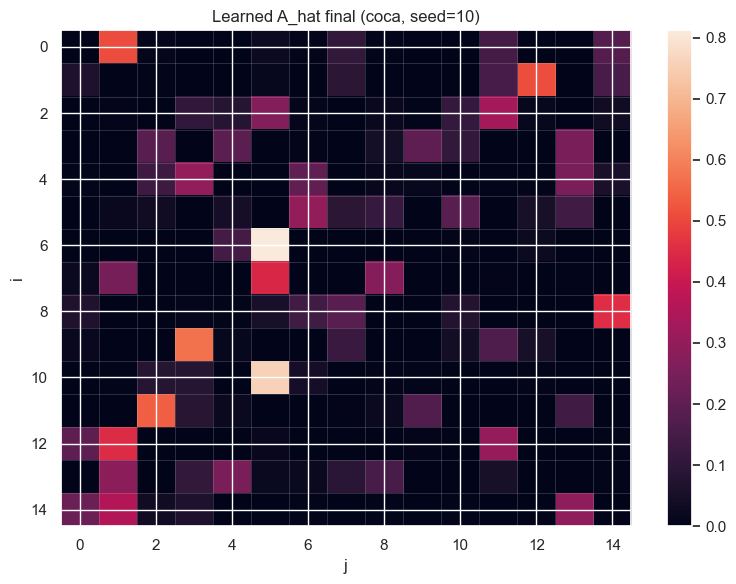

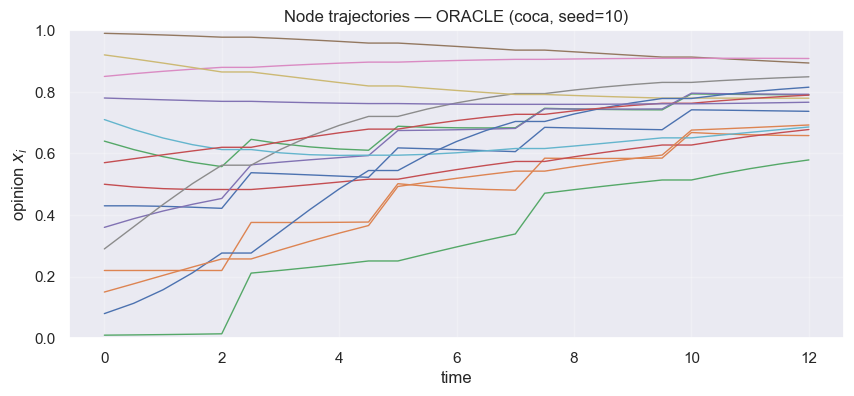

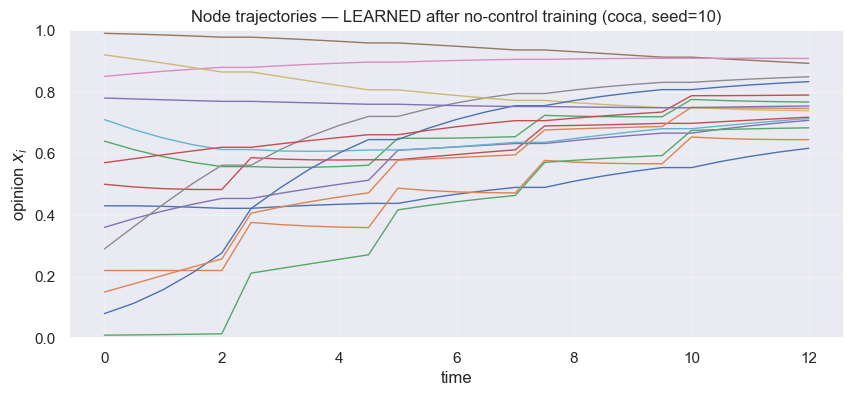


=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.4122936704953508


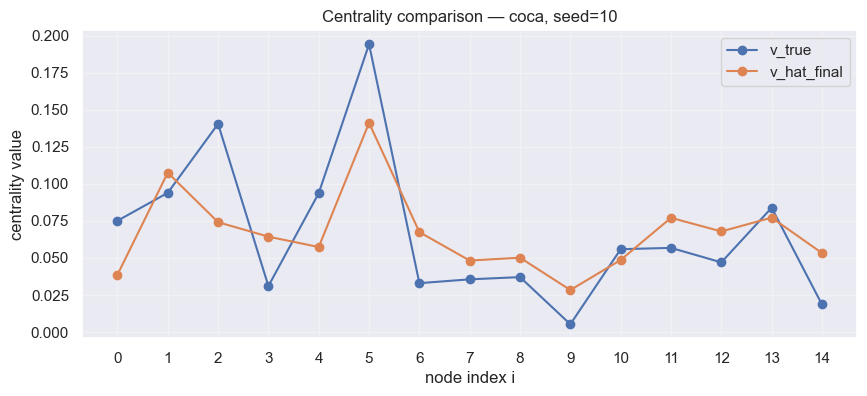

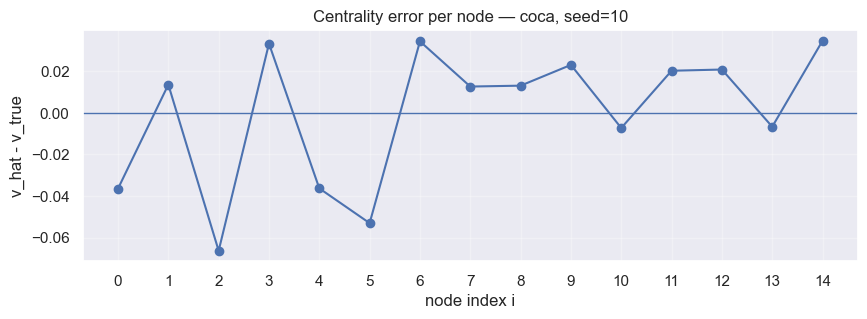

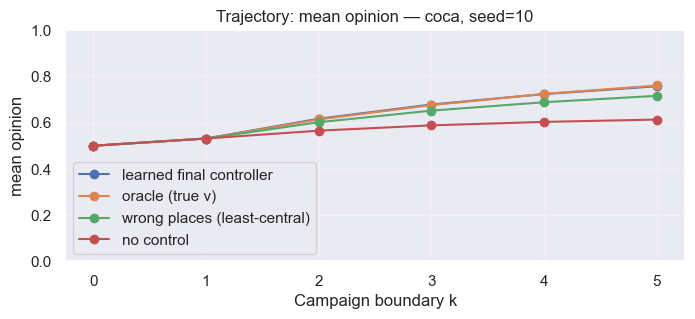


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.0
learned states[1] vs nocontrol states[1] L_inf: 0.0

=== DETAILED ANALYSIS: friedkinjohnsen | SEED 10 ===
x0_train: [0.01 0.22 0.78 0.15 0.43 0.71 0.5  0.29 0.99 0.36 0.85 0.08 0.92 0.57
 0.64]
x0_eval : [0.43 0.22 0.64 0.5  0.36 0.99 0.85 0.29 0.92 0.71 0.08 0.15 0.01 0.57
 0.78]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 1.0017820031950908
edges: 39
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999999408028089
row_sum_mean: 1.0000000140959553
row_sum_max: 1.0000000772997737
asym: 0.9751116214376555
edges: 210
sink_sizes: [15]
has_singleton_sink: False


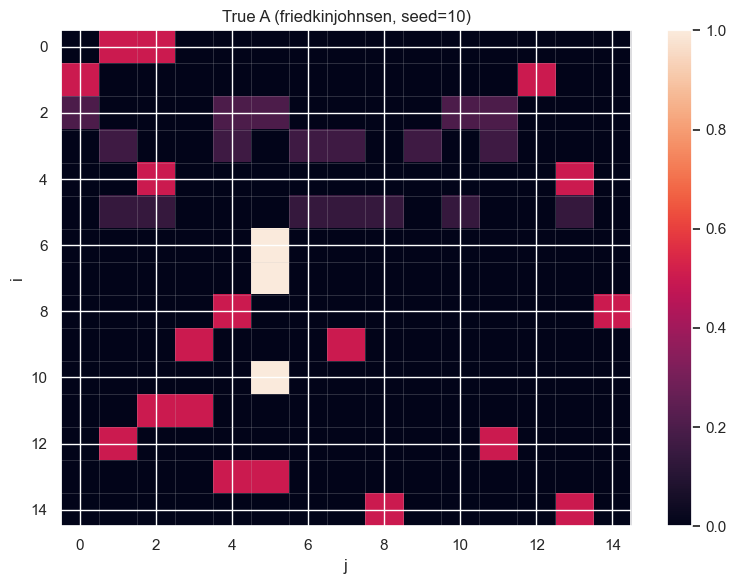

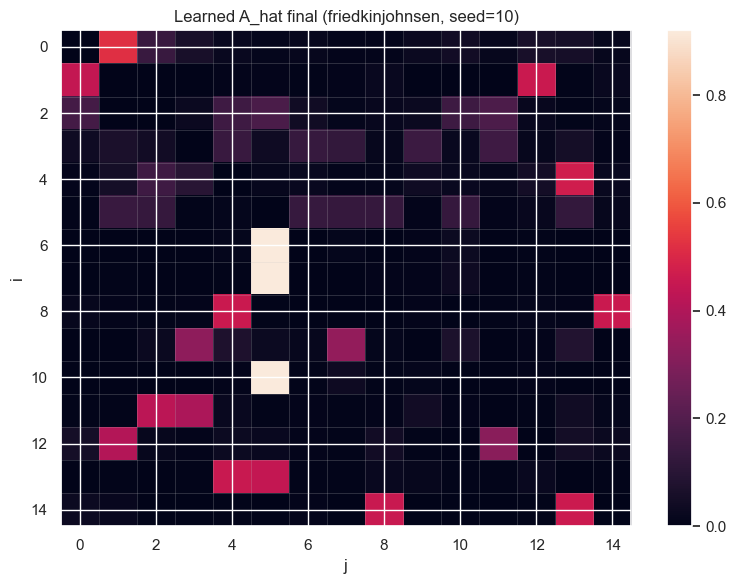

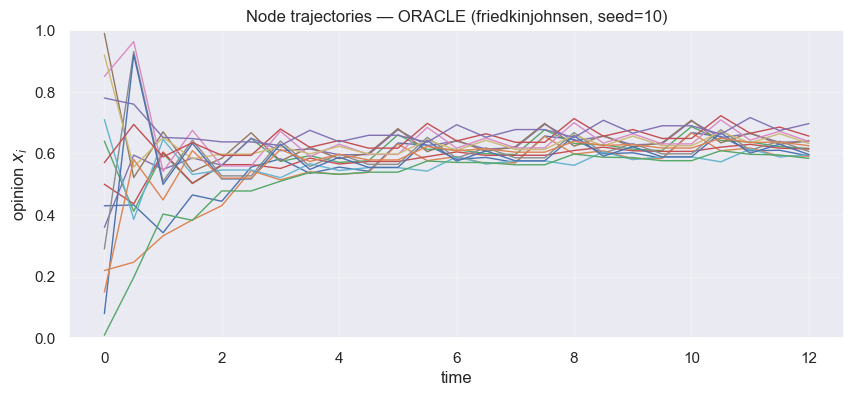

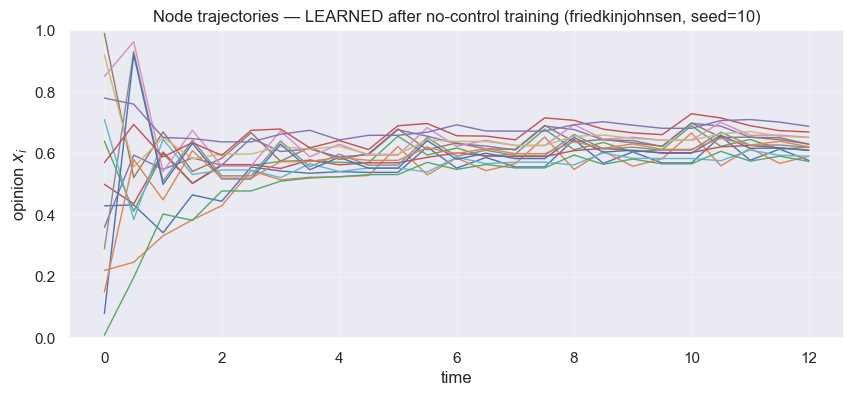


=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.22749238852085052


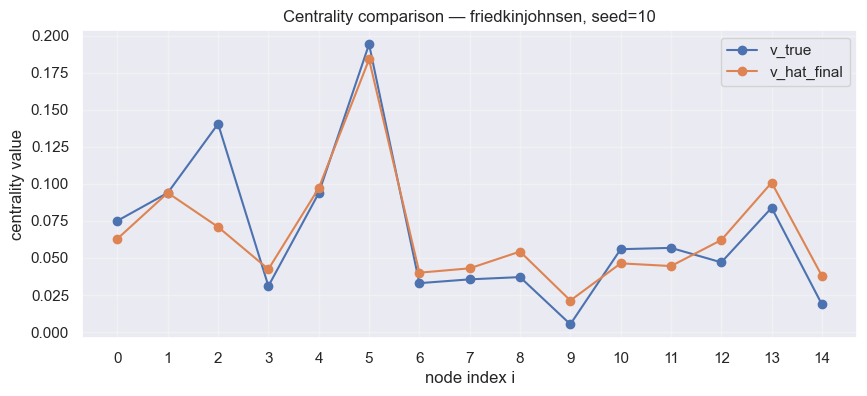

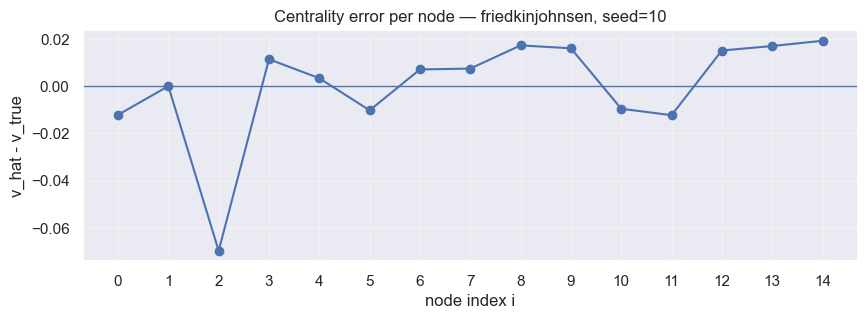

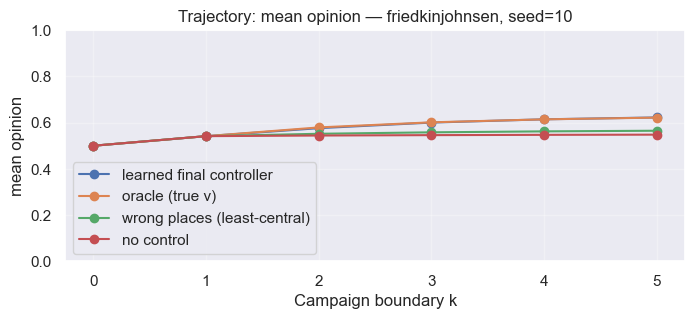


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.0
learned states[1] vs nocontrol states[1] L_inf: 0.0

=== DETAILED ANALYSIS: hegselmannkrause | SEED 10 ===
x0_train: [0.01 0.22 0.78 0.15 0.43 0.71 0.5  0.29 0.99 0.36 0.85 0.08 0.92 0.57
 0.64]
x0_eval : [0.43 0.22 0.64 0.5  0.36 0.99 0.85 0.29 0.92 0.71 0.08 0.15 0.01 0.57
 0.78]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 1.0017820031950908
edges: 39
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999998562270775
row_sum_mean: 0.9999999816529452
row_sum_max: 1.0000000942964107
asym: 0.743321373125268
edges: 210
sink_sizes: [15]
has_singleton_sink: False


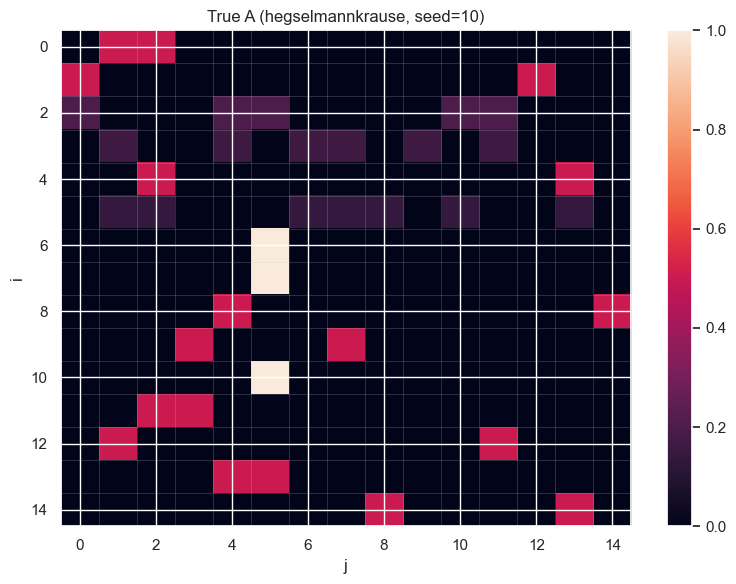

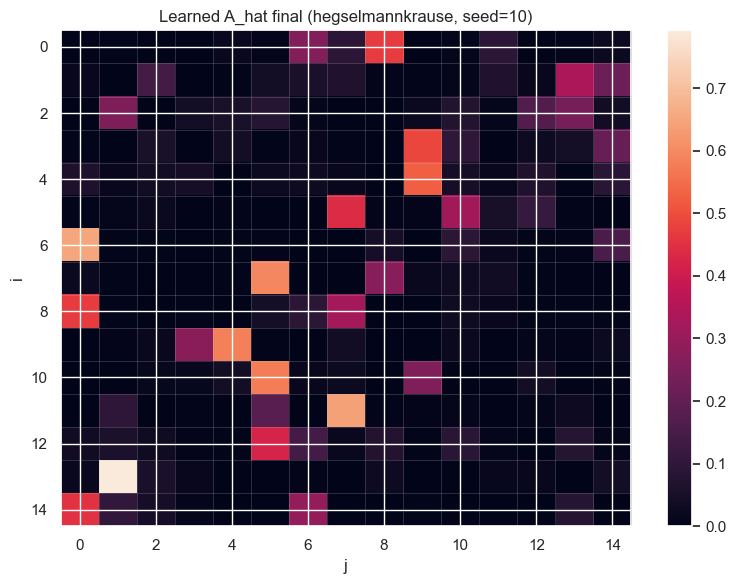

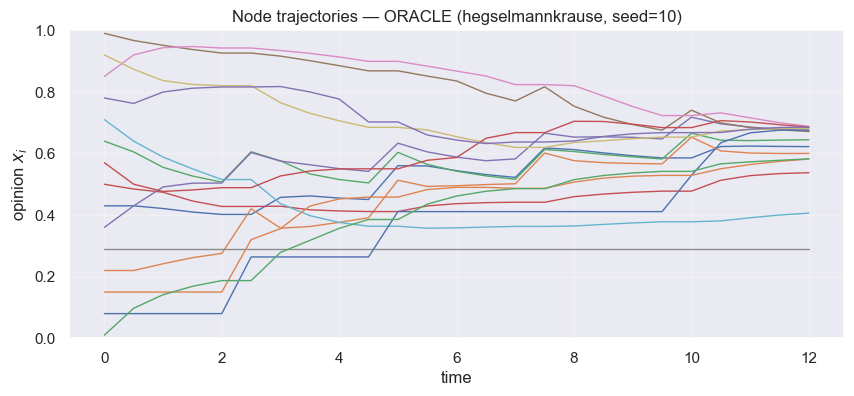

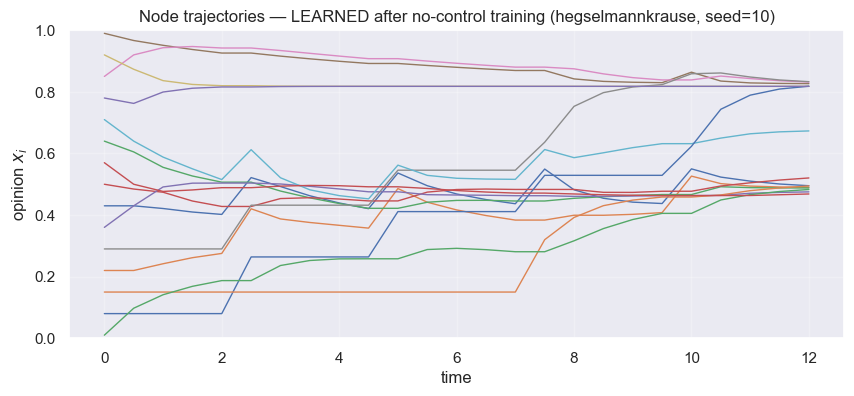


=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.6889783517967226


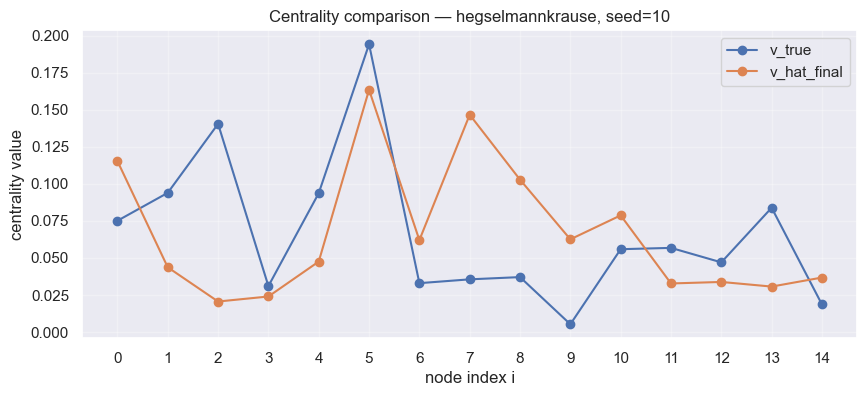

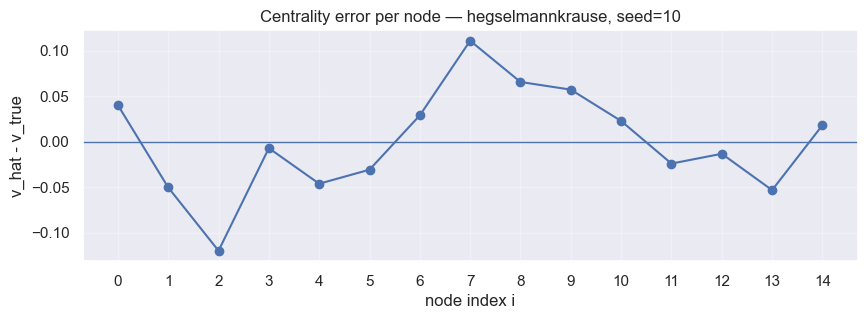

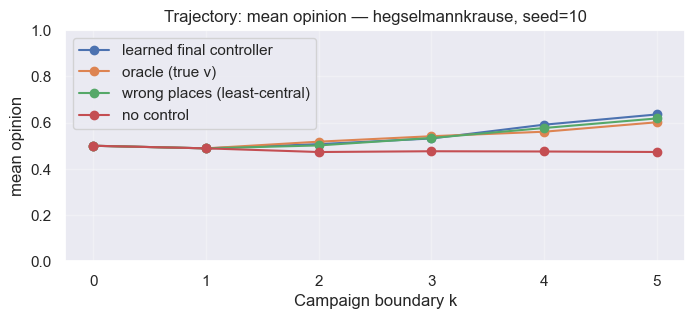


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.0
learned states[1] vs nocontrol states[1] L_inf: 0.0

=== DETAILED ANALYSIS: nonlinearinfluence | SEED 10 ===
x0_train: [0.01 0.22 0.78 0.15 0.43 0.71 0.5  0.29 0.99 0.36 0.85 0.08 0.92 0.57
 0.64]
x0_eval : [0.43 0.22 0.64 0.5  0.36 0.99 0.85 0.29 0.92 0.71 0.08 0.15 0.01 0.57
 0.78]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999998
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 1.0017820031950908
edges: 39
sink_sizes: [15]
has_singleton_sink: False

=== GRAPH SANITY (LEARNED FINAL) ===
diag_max: 0.0
row_sum_min: 0.9999999336432666
row_sum_mean: 1.000000013942675
row_sum_max: 1.0000001547741704
asym: 1.0107170486491717
edges: 210
sink_sizes: [15]
has_singleton_sink: False


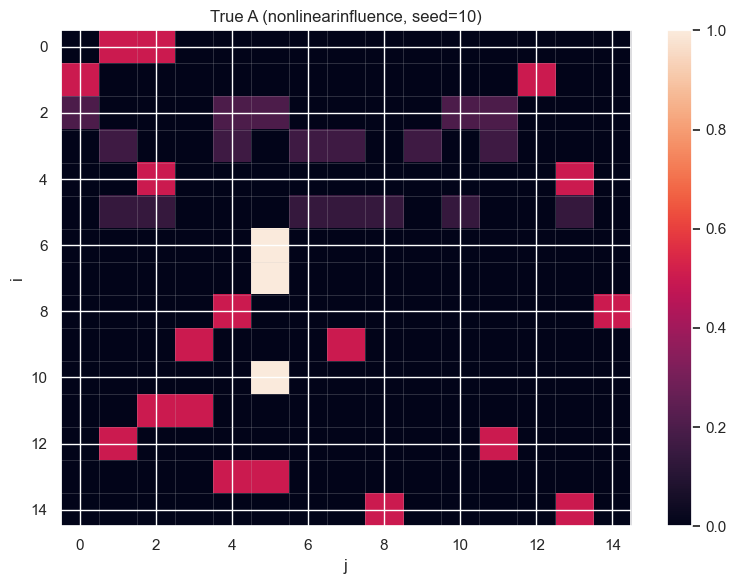

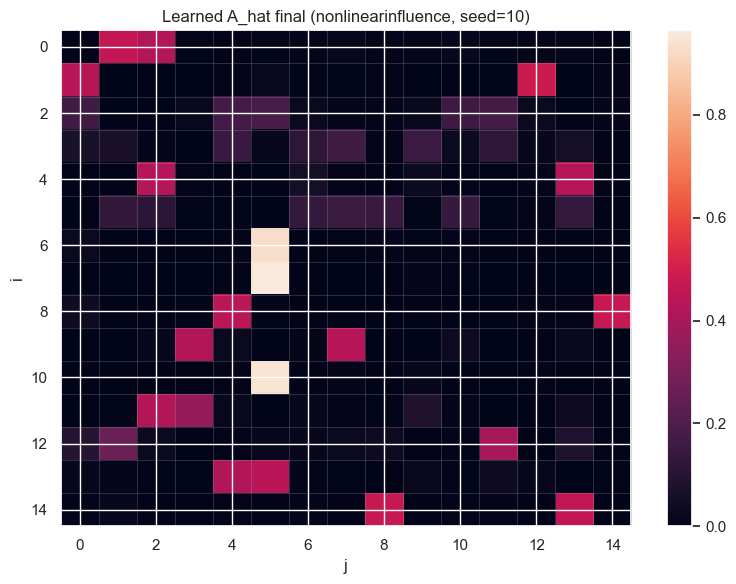

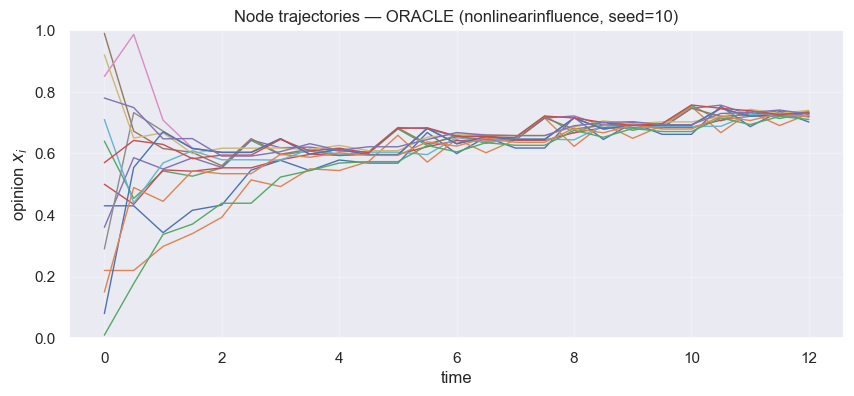

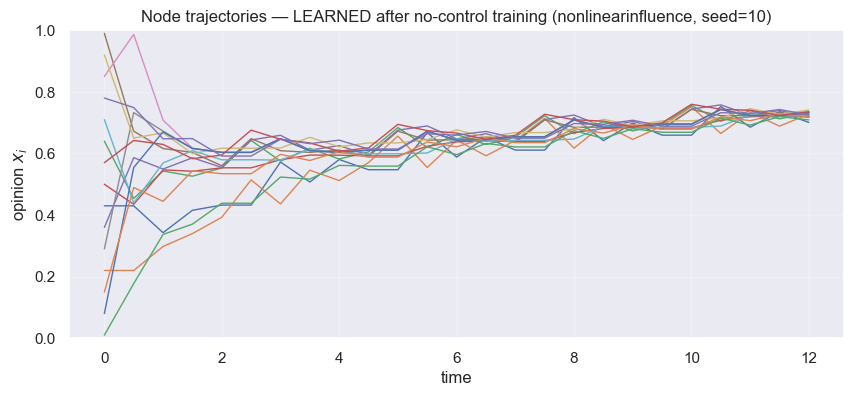


=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat_final - v_true): 0.1636651463721811


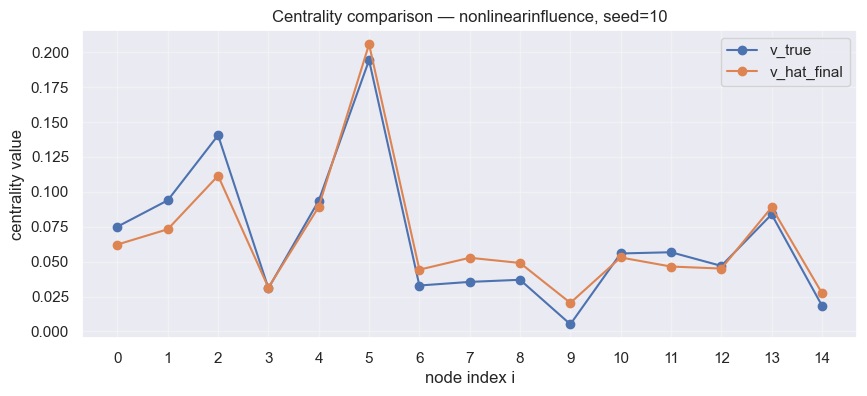

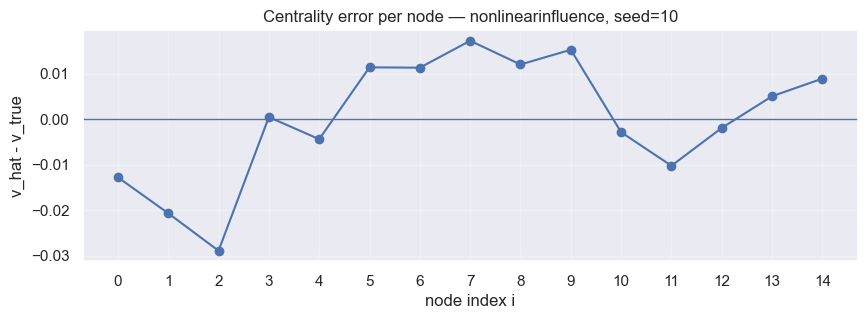

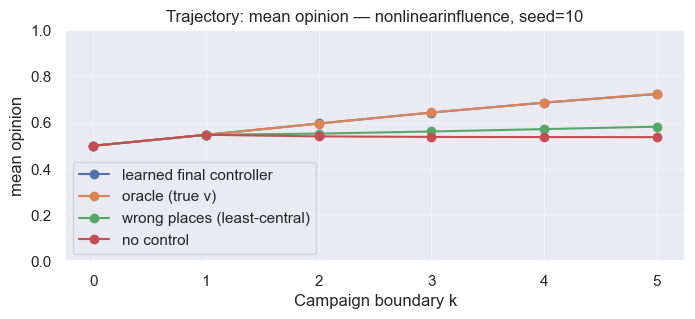


=== CAMPAIGN-0 OVERLAP CHECK ===
learned states[1] vs oracle states[1] L_inf: 0.0
learned states[1] vs nocontrol states[1] L_inf: 0.0


In [ ]:
# =========================================================
# Detailed graph / rollout comparison for the final learned model
# Run for ALL dynamics, as in the previous repeated notebook.
# =========================================================

for DYNAMICS in DYNAMICS_LIST:
    art = art_by_dyn[DYNAMICS]

    A_true = np.asarray(art["A_true"], dtype=float)
    v_true = np.asarray(art["v_true"], dtype=float)
    A_hat_final = np.asarray(art["A_hat_final"], dtype=float)
    v_hat_final = np.asarray(art["v_hat_final"], dtype=float)

    x0_train = np.asarray(art["x0_train"], dtype=float)
    x0_eval = np.asarray(art["x0_eval"], dtype=float)

    states_learn = np.asarray(art["states_learn"], dtype=float)
    states_oracle = np.asarray(art["states_oracle"], dtype=float)
    states_noc = np.asarray(art["states_nocontrol_eval"], dtype=float)

    N = states_learn.shape[1]
    K_total = states_learn.shape[0] - 1

    print("\n" + "=" * 80)
    print(f"=== DETAILED ANALYSIS: {DYNAMICS} | SEED {SEED_TO_PLOT} ===")
    print("=" * 80)
    print("x0_train:", x0_train)
    print("x0_eval :", x0_eval)

    print("\n=== GRAPH SANITY (TRUE) ===")
    for k, v in graph_sanity(A_true).items():
        print(f"{k}: {v}")

    print("\n=== GRAPH SANITY (LEARNED FINAL) ===")
    for k, v in graph_sanity(A_hat_final).items():
        print(f"{k}: {v}")

    show_matrix_with_cell_grid(
        A_true,
        title=f"True A ({DYNAMICS}, seed={SEED_TO_PLOT})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )
    show_matrix_with_cell_grid(
        A_hat_final,
        title=f"Learned A_hat final ({DYNAMICS}, seed={SEED_TO_PLOT})",
        grid_alpha=0.25,
        grid_lw=0.6,
    )

    env_template = make_env_with_dynamics(
        env_factory,
        seed=SEED_TO_PLOT,
        dynamics_model=DYNAMICS,
    )

    env_learn, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=SEED_TO_PLOT + 999_999,
        initial_opinions=x0_eval,
    )
    env_or, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=SEED_TO_PLOT + 999_999,
        initial_opinions=x0_eval,
    )
    env_nc, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=SEED_TO_PLOT + 999_999,
        initial_opinions=x0_eval,
    )

    le_out = rollout_with_v_intermediate(env_learn, x0_eval, K_total, B_campaign, v_hat_final)
    or_out = rollout_with_v_intermediate(env_or, x0_eval, K_total, B_campaign, v_true)
    nc_out = rollout_with_v_intermediate(env_nc, x0_eval, K_total, B_campaign, None)

    order = np.argsort(v_true)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(v_true) + 1)
    v_anti = 1.0 / ranks
    v_anti = v_anti / v_anti.sum()

    env_anti, _ = _fresh_env_from_template(
        env_template,
        repeat_seed=SEED_TO_PLOT + 999_999,
        initial_opinions=x0_eval,
    )
    anti_out = rollout_with_v_intermediate(env_anti, x0_eval, K_total, B_campaign, v_anti)

    dt = float(getattr(env_template, "t_s", 1.0))
    X_le, T_le = concat_intermediate(le_out["intermediate_states_list"], le_out["intermediate_times_list"], dt=dt)
    X_or, T_or = concat_intermediate(or_out["intermediate_states_list"], or_out["intermediate_times_list"], dt=dt)

    plot_impulse_node_trajectories(
        X_or,
        T_or,
        title=f"Node trajectories — ORACLE ({DYNAMICS}, seed={SEED_TO_PLOT})",
    )
    plot_impulse_node_trajectories(
        X_le,
        T_le,
        title=f"Node trajectories — LEARNED after no-control training ({DYNAMICS}, seed={SEED_TO_PLOT})",
    )

    print("\n=== CENTRALITY COMPARISON (by node index) ===")
    print("L1(v_hat_final - v_true):", float(np.sum(np.abs(v_hat_final - v_true))))

    idx = np.arange(N)
    diff = v_hat_final - v_true

    plt.figure(figsize=(10, 4))
    plt.plot(idx, v_true, marker="o", label="v_true")
    plt.plot(idx, v_hat_final, marker="o", label="v_hat_final")
    plt.xlabel("node index i")
    plt.ylabel("centrality value")
    plt.title(f"Centrality comparison — {DYNAMICS}, seed={SEED_TO_PLOT}")
    plt.xticks(idx)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.axhline(0.0, linewidth=1)
    plt.plot(idx, diff, marker="o")
    plt.xlabel("node index i")
    plt.ylabel("v_hat - v_true")
    plt.title(f"Centrality error per node — {DYNAMICS}, seed={SEED_TO_PLOT}")
    plt.xticks(idx)
    plt.grid(True, alpha=0.3)
    plt.show()

    states_learn_eval = np.asarray(le_out["states"], dtype=float)
    states_or_eval = np.asarray(or_out["states"], dtype=float)
    states_nc_eval = np.asarray(nc_out["states"], dtype=float)
    states_anti_eval = np.asarray(anti_out["states"], dtype=float)

    mean_learn = states_learn_eval.mean(axis=1)
    mean_or = states_or_eval.mean(axis=1)
    mean_nc = states_nc_eval.mean(axis=1)
    mean_anti = states_anti_eval.mean(axis=1)

    plt.figure(figsize=(8, 3))
    plt.plot(mean_learn, marker="o", label="learned final controller")
    plt.plot(mean_or, marker="o", label="oracle (true v)")
    plt.plot(mean_anti, marker="o", label="wrong places (least-central)")
    plt.plot(mean_nc, marker="o", label="no control")
    plt.xlabel("Campaign boundary k")
    plt.ylabel("mean opinion")
    plt.title(f"Trajectory: mean opinion — {DYNAMICS}, seed={SEED_TO_PLOT}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0, 1)
    plt.show()

    print("\n=== CAMPAIGN-0 OVERLAP CHECK ===")
    print(
        "learned states[1] vs oracle states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_or_eval[1]))),
    )
    print(
        "learned states[1] vs nocontrol states[1] L_inf:",
        float(np.max(np.abs(states_learn_eval[1] - states_nc_eval[1]))),
    )